In [4]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda


In [5]:
from getpass import getpass

github_token = getpass('GitHub token: ')
github_user  = 'iremcesur'
repo_name    = 'CENG467_Midterm_310201051'

!git clone https://{github_token}@github.com/{github_user}/{repo_name}.git
%cd {repo_name}

!git config user.email "iremcesur310201051@gmail.com"
!git config user.name  "iremcesur"
!git config pull.rebase false

print("✓ Repo ready")

GitHub token: ··········
Cloning into 'CENG467_Midterm_310201051'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 89 (delta 23), reused 68 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 2.26 MiB | 7.40 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/CENG467_Midterm_310201051
✓ Repo ready


In [6]:
import random
import numpy as np
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

!pip install -q sacrebleu bert-score transformers datasets sentencepiece

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

print(f"✓ Seed: {SEED}")
print(f"✓ Libraries ready")
print(f"✓ Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00
✓ Seed: 42
✓ Libraries ready
✓ Device: cuda


In [7]:
from datasets import load_dataset

print("Loading Multi30k (de→en)...")
raw = load_dataset("bentrevett/multi30k")

print(f"Train : {len(raw['train']):,} sentence pairs")
print(f"Val   : {len(raw['validation']):,} sentence pairs")
print(f"Test  : {len(raw['test']):,} sentence pairs")

print("\n--- Sample sentence pairs (first 3) ---")
for i in range(3):
    ex = raw['train'][i]
    print(f"  DE: {ex['de']}")
    print(f"  EN: {ex['en']}")
    print()

Loading Multi30k (de→en)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train : 29,000 sentence pairs
Val   : 1,014 sentence pairs
Test  : 1,000 sentence pairs

--- Sample sentence pairs (first 3) ---
  DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
  EN: Two young, White males are outside near many bushes.

  DE: Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.
  EN: Several men in hard hats are operating a giant pulley system.

  DE: Ein kleines Mädchen klettert in ein Spielhaus aus Holz.
  EN: A little girl climbing into a wooden playhouse.



In [8]:
import re
from collections import Counter

def tokenize(text):
    """Lowercase, split on whitespace/punctuation boundaries."""
    text = text.lower().strip()
    text = re.sub(r"([.!?,\"':;)(])", r" \1 ", text)
    return text.split()

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
SPECIALS = ['<pad>', '<unk>', '<sos>', '<eos>']
MIN_FREQ = 2

def build_vocab(sentences, min_freq=MIN_FREQ):
    counter = Counter()
    for sent in sentences:
        counter.update(tokenize(sent))
    vocab = SPECIALS[:]
    vocab += [tok for tok, cnt in counter.most_common() if cnt >= min_freq]
    tok2id = {tok: i for i, tok in enumerate(vocab)}
    id2tok = {i: tok for tok, i in tok2id.items()}
    return tok2id, id2tok

print("Building vocabularies...")
src_tok2id, src_id2tok = build_vocab([ex['de'] for ex in raw['train']])
tgt_tok2id, tgt_id2tok = build_vocab([ex['en'] for ex in raw['train']])

SRC_VOCAB = len(src_tok2id)
TGT_VOCAB = len(tgt_tok2id)

print(f"Source (DE) vocabulary size : {SRC_VOCAB:,}")
print(f"Target (EN) vocabulary size : {TGT_VOCAB:,}")

src_lengths = [len(tokenize(ex['de'])) for ex in raw['train']]
tgt_lengths = [len(tokenize(ex['en'])) for ex in raw['train']]
print(f"\nDE mean length: {np.mean(src_lengths):.1f}, max: {max(src_lengths)}")
print(f"EN mean length: {np.mean(tgt_lengths):.1f}, max: {max(tgt_lengths)}")

Building vocabularies...
Source (DE) vocabulary size : 7,822
Target (EN) vocabulary size : 5,924

DE mean length: 12.4, max: 44
EN mean length: 13.0, max: 40


In [9]:
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 50

def encode(tokens, tok2id, max_len=MAX_LEN):
    ids = [SOS_IDX]
    for tok in tokens[:max_len]:
        ids.append(tok2id.get(tok, UNK_IDX))
    ids.append(EOS_IDX)
    return ids

class TranslationDataset(Dataset):
    def __init__(self, hf_split):
        self.pairs = [
            (
                encode(tokenize(ex['de']), src_tok2id),
                encode(tokenize(ex['en']), tgt_tok2id),
            )
            for ex in hf_split
        ]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_max = max(len(s) for s in src_batch)
    tgt_max = max(len(t) for t in tgt_batch)

    src_padded = torch.zeros(len(src_batch), src_max, dtype=torch.long)
    tgt_padded = torch.zeros(len(tgt_batch), tgt_max, dtype=torch.long)

    for i, (s, t) in enumerate(zip(src_batch, tgt_batch)):
        src_padded[i, :len(s)] = torch.tensor(s)
        tgt_padded[i, :len(t)] = torch.tensor(t)

    return src_padded, tgt_padded

BATCH_SIZE = 128

train_dataset = TranslationDataset(raw['train'])
val_dataset   = TranslationDataset(raw['validation'])
test_dataset  = TranslationDataset(raw['test'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

print(f"✓ DataLoaders ready")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

✓ DataLoaders ready
  Train batches : 227
  Val batches   : 8
  Test batches  : 8


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    """
    Bidirectional GRU encoder.
    Forward + backward final hidden states birleştirilip
    decoder'ın başlangıç hidden state'i için HIDDEN_DIM'e project edilir.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))       # (batch, src_len, embed_dim)
        outputs, hidden = self.rnn(embedded)               # outputs: (batch, src_len, hidden*2)
        # hidden[-2] = top forward, hidden[-1] = top backward
        hidden_cat  = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden*2)
        hidden_proj = torch.tanh(self.fc(hidden_cat))             # (batch, hidden)
        hidden_proj = hidden_proj.unsqueeze(0)                    # (1, batch, hidden)
        return outputs, hidden_proj

print("✓ Encoder defined")

✓ Encoder defined


In [11]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention.
    score(s, h) = v^T tanh(W1*s + W2*h)
    s = decoder hidden state, h = encoder output.
    """
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, dec_hidden_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim, bias=False)
        self.v  = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden : (1, batch, dec_hidden)
        # encoder_outputs: (batch, src_len, enc_hidden*2)
        src_len = encoder_outputs.size(1)
        s = decoder_hidden.permute(1, 0, 2).expand(-1, src_len, -1)  # (batch, src_len, dec_hidden)
        energy = torch.tanh(self.W1(s) + self.W2(encoder_outputs))   # (batch, src_len, dec_hidden)
        scores = self.v(energy).squeeze(2)                            # (batch, src_len)
        attn_weights = F.softmax(scores, dim=1)                       # (batch, src_len)
        context = torch.bmm(
            attn_weights.unsqueeze(1),   # (batch, 1, src_len)
            encoder_outputs              # (batch, src_len, enc_hidden*2)
        ).squeeze(1)                     # (batch, enc_hidden*2)
        return context, attn_weights

print("✓ Bahdanau Attention defined")

✓ Bahdanau Attention defined


In [12]:
class Decoder(nn.Module):
    """
    Single-layer GRU decoder with Bahdanau attention.
    Her adımda [embedding || context_vector] input olarak alır.
    """
    def __init__(self, vocab_size, embed_dim, enc_hidden_dim, dec_hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(enc_hidden_dim, dec_hidden_dim)
        self.rnn = nn.GRU(
            embed_dim + enc_hidden_dim * 2,
            dec_hidden_dim,
            batch_first=True,
        )
        self.fc_out = nn.Linear(
            dec_hidden_dim + enc_hidden_dim * 2 + embed_dim,
            vocab_size
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token     : (batch,)
        # hidden        : (1, batch, hidden)
        # encoder_outputs: (batch, src_len, enc_hidden*2)
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))  # (batch, 1, embed)
        context, attn_weights = self.attention(hidden, encoder_outputs)  # (batch, enc*2)
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)  # (batch, 1, embed+enc*2)
        output, hidden = self.rnn(rnn_input, hidden)                     # (batch, 1, dec_hidden)
        output   = output.squeeze(1)                                     # (batch, dec_hidden)
        embedded = embedded.squeeze(1)                                   # (batch, embed)
        pred = self.fc_out(torch.cat([output, context, embedded], dim=1))# (batch, vocab)
        return pred, hidden, attn_weights

print("✓ Decoder defined")

✓ Decoder defined


In [13]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src : (batch, src_len)
        # tgt : (batch, tgt_len)
        batch_size = src.size(0)
        tgt_len    = tgt.size(1)
        tgt_vocab  = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab).to(src.device)
        encoder_outputs, hidden = self.encoder(src)

        dec_input = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            pred, hidden, _ = self.decoder(dec_input, hidden, encoder_outputs)
            outputs[:, t, :] = pred
            teacher_force = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if teacher_force else pred.argmax(1)

        return outputs


# Hyperparameters
EMB_DIM  = 256
HID_DIM  = 512
N_LAYERS = 2
DROPOUT  = 0.5

encoder = Encoder(SRC_VOCAB, EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(TGT_VOCAB, EMB_DIM, HID_DIM, HID_DIM, DROPOUT)
seq2seq = Seq2Seq(encoder, decoder).to(device)

n_params = sum(p.numel() for p in seq2seq.parameters() if p.requires_grad)
print(f"✓ Seq2Seq ready")
print(f"  Trainable parameters: {n_params:,}")

✓ Seq2Seq ready
  Trainable parameters: 25,298,212


In [15]:
import math, time

def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.xavier_uniform_(param.data)
        else:
            nn.init.zeros_(param.data)

seq2seq.apply(init_weights)

optimizer = torch.optim.Adam(seq2seq.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.5)
        output_flat = output[:, 1:, :].reshape(-1, output.size(-1))
        tgt_flat    = tgt[:, 1:].reshape(-1)
        loss = criterion(output_flat, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0.0)
            output_flat = output[:, 1:, :].reshape(-1, output.size(-1))
            tgt_flat    = tgt[:, 1:].reshape(-1)
            loss = criterion(output_flat, tgt_flat)
            total_loss += loss.item()
    return total_loss / len(loader)

N_EPOCHS  = 15
PATIENCE  = 3
best_val  = float('inf')
patience_counter = 0
train_losses, val_losses = [], []
CKPT_PATH = 'q4_translation/seq2seq_best.pt'
os.makedirs('q4_translation', exist_ok=True)

print(f"Training Seq2Seq (max {N_EPOCHS} epochs, patience={PATIENCE})...")
print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Train PPL':>10} {'Val PPL':>8} {'Time':>7}")
print('-' * 60)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    tr_loss  = train_epoch(seq2seq, train_loader, optimizer, criterion)
    val_loss = eval_epoch(seq2seq, val_loader, criterion)
    elapsed  = time.time() - t0

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    print(f"{epoch:>5} {tr_loss:>12.4f} {val_loss:>10.4f} "
          f"{math.exp(tr_loss):>10.2f} {math.exp(val_loss):>8.2f} {elapsed:>6.0f}s")

    if val_loss < best_val:
        best_val = val_loss
        patience_counter = 0
        torch.save(seq2seq.state_dict(), CKPT_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n✓ Early stopping at epoch {epoch}.")
            break

seq2seq.load_state_dict(torch.load(CKPT_PATH))
print(f"\n✓ Best model restored (val loss = {best_val:.4f}, PPL = {math.exp(best_val):.2f})")

Training Seq2Seq (max 15 epochs, patience=3)...
Epoch   Train Loss   Val Loss  Train PPL  Val PPL    Time
------------------------------------------------------------
    1       4.9730     4.6464     144.46   104.21    112s
    2       4.0543     4.1504      57.65    63.46    111s
    3       3.4034     3.6944      30.07    40.22    112s
    4       2.9650     3.4587      19.40    31.77    112s
    5       2.6526     3.3013      14.19    27.15    112s
    6       2.4017     3.2887      11.04    26.81    113s
    7       2.1953     3.2432       8.98    25.62    113s
    8       1.9960     3.2653       7.36    26.19    113s
    9       1.8525     3.2354       6.38    25.42    112s
   10       1.7139     3.2683       5.55    26.27    111s
   11       1.6153     3.2847       5.03    26.70    112s
   12       1.5033     3.2693       4.50    26.29    111s

✓ Early stopping at epoch 12.

✓ Best model restored (val loss = 3.2354, PPL = 25.42)


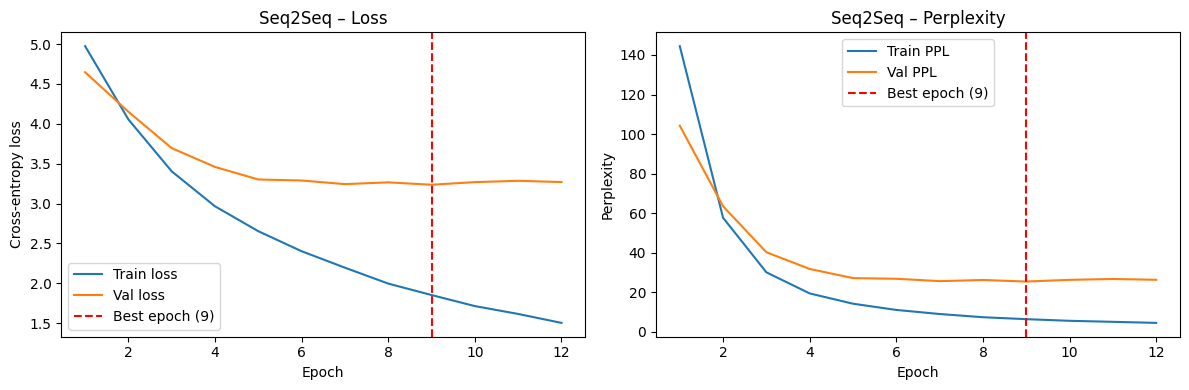

✓ Saved


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train loss')
axes[0].plot(epochs_range, val_losses,   label='Val loss')
axes[0].axvline(x=9, color='red', linestyle='--', label='Best epoch (9)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Seq2Seq – Loss')
axes[0].legend()

axes[1].plot(epochs_range, [math.exp(l) for l in train_losses], label='Train PPL')
axes[1].plot(epochs_range, [math.exp(l) for l in val_losses],   label='Val PPL')
axes[1].axvline(x=9, color='red', linestyle='--', label='Best epoch (9)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Seq2Seq – Perplexity')
axes[1].legend()

plt.tight_layout()
os.makedirs('q4_translation/figures', exist_ok=True)
plt.savefig('q4_translation/figures/seq2seq_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

In [17]:
from transformers import MarianMTModel, MarianTokenizer

MARIAN_MODEL = 'Helsinki-NLP/opus-mt-de-en'
print(f"Loading {MARIAN_MODEL}...")

marian_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL)
marian_model     = MarianMTModel.from_pretrained(MARIAN_MODEL).to(device)
marian_model.eval()

n_marian = sum(p.numel() for p in marian_model.parameters())
print(f"✓ MarianMT ready")
print(f"  Parameters : {n_marian:,}")
print(f"  Vocab size : {marian_tokenizer.vocab_size:,}")

Loading Helsinki-NLP/opus-mt-de-en...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

✓ MarianMT ready
  Parameters : 133,905,920
  Vocab size : 58,101


In [18]:
# ── Seq2Seq greedy decoding ───────────────────────────────────────────────────
def translate_seq2seq(sentence, max_len=50):
    seq2seq.eval()
    with torch.no_grad():
        tokens = tokenize(sentence)
        src_ids = encode(tokens, src_tok2id)
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

        enc_out, hidden = seq2seq.encoder(src_tensor)
        dec_input = torch.tensor([SOS_IDX], dtype=torch.long).to(device)
        output_tokens = []

        for _ in range(max_len):
            pred, hidden, _ = seq2seq.decoder(dec_input, hidden, enc_out)
            top1 = pred.argmax(1)
            if top1.item() == EOS_IDX:
                break
            output_tokens.append(tgt_id2tok[top1.item()])
            dec_input = top1

    return ' '.join(output_tokens)


# ── MarianMT beam-search decoding ─────────────────────────────────────────────
def translate_marian(sentences, batch_size=64):
    results = []
    marian_model.eval()
    with torch.no_grad():
        for i in range(0, len(sentences), batch_size):
            batch = sentences[i : i + batch_size]
            encoded = marian_tokenizer(
                batch,
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=128,
            ).to(device)
            translated = marian_model.generate(
                **encoded,
                num_beams=4,
                max_length=128,
                early_stopping=True,
            )
            decoded = marian_tokenizer.batch_decode(translated, skip_special_tokens=True)
            results.extend(decoded)
    return results


# ── Sanity check ──────────────────────────────────────────────────────────────
sample_de = raw['test'][0]['de']
sample_en = raw['test'][0]['en']

print(f"DE (source)   : {sample_de}")
print(f"EN (reference): {sample_en}")
print(f"Seq2Seq output: {translate_seq2seq(sample_de)}")
print(f"Marian output : {translate_marian([sample_de])[0]}")

DE (source)   : Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
EN (reference): A man in an orange hat starring at something.
Seq2Seq output: a man in an orange hat is tomatoes .
Marian output : A man with an orange hat staring at something.


In [19]:
from tqdm.notebook import tqdm

test_src  = [ex['de'] for ex in raw['test']]
test_refs = [ex['en'] for ex in raw['test']]

# ── Seq2Seq ───────────────────────────────────────────────────────────────────
print("Translating test set with Seq2Seq (greedy)...")
t0 = time.time()
seq2seq_hyps = [translate_seq2seq(s) for s in tqdm(test_src)]
seq2seq_time = time.time() - t0
print(f"✓ Done in {seq2seq_time:.1f}s ({seq2seq_time/len(test_src):.3f}s/sentence)")

# ── MarianMT ──────────────────────────────────────────────────────────────────
print("\nTranslating test set with MarianMT (beam=4)...")
t0 = time.time()
marian_hyps = translate_marian(test_src)
marian_time = time.time() - t0
print(f"✓ Done in {marian_time:.1f}s ({marian_time/len(test_src):.3f}s/sentence)")

Translating test set with Seq2Seq (greedy)...


  0%|          | 0/1000 [00:00<?, ?it/s]

✓ Done in 15.3s (0.015s/sentence)

Translating test set with MarianMT (beam=4)...
✓ Done in 16.1s (0.016s/sentence)


In [20]:
import sacrebleu
from nltk.translate.meteor_score import meteor_score as nltk_meteor
from bert_score import score as bert_score_fn

def compute_all_metrics(hypotheses, references, model_name=""):
    print(f"Computing metrics for {model_name}...")

    # BLEU (corpus-level, sacrebleu)
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])

    # ChrF (corpus-level, sacrebleu)
    chrf = sacrebleu.corpus_chrf(hypotheses, [references])

    # METEOR (sentence-level average)
    meteor_scores = [
        nltk_meteor([ref.split()], hyp.split())
        for hyp, ref in zip(hypotheses, references)
    ]
    meteor_avg = float(np.mean(meteor_scores)) * 100

    # BERTScore
    P, R, F1 = bert_score_fn(
        hypotheses, references,
        lang='en',
        rescale_with_baseline=True,
        verbose=False,
    )
    bertscore_f1 = float(F1.mean()) * 100

    return {
        'BLEU'      : round(bleu.score, 2),
        'ChrF'      : round(chrf.score, 2),
        'METEOR'    : round(meteor_avg, 2),
        'BERTScore' : round(bertscore_f1, 2),
    }

seq2seq_metrics = compute_all_metrics(seq2seq_hyps, test_refs, "Seq2Seq")
marian_metrics  = compute_all_metrics(marian_hyps,  test_refs, "MarianMT")

print("\n─── Results ───────────────────────────────────")
print(f"{'Metric':<12} {'Seq2Seq':>10} {'MarianMT':>10} {'Δ':>8}")
print("─" * 44)
for metric in ['BLEU', 'ChrF', 'METEOR', 'BERTScore']:
    s = seq2seq_metrics[metric]
    m = marian_metrics[metric]
    print(f"{metric:<12} {s:>10.2f} {m:>10.2f} {m-s:>+8.2f}")

Computing metrics for Seq2Seq...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing metrics for MarianMT...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



─── Results ───────────────────────────────────
Metric          Seq2Seq   MarianMT        Δ
────────────────────────────────────────────
BLEU              24.21      39.66   +15.45
ChrF              46.94      60.60   +13.66
METEOR            52.00      69.26   +17.26
BERTScore         49.88      80.89   +31.01


In [21]:
import json

results = {
    'seq2seq': {
        'metrics': seq2seq_metrics,
        'inference_time_total': seq2seq_time,
        'inference_time_per_sentence': seq2seq_time / len(test_src),
        'val_ppl': math.exp(best_val),
        'best_epoch': 9,
        'n_params': sum(p.numel() for p in seq2seq.parameters() if p.requires_grad),
    },
    'marian': {
        'metrics': marian_metrics,
        'inference_time_total': marian_time,
        'inference_time_per_sentence': marian_time / len(test_src),
        'n_params': sum(p.numel() for p in marian_model.parameters()),
    }
}

os.makedirs('q4_translation/results', exist_ok=True)
with open('q4_translation/results/q4_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results saved")
print(json.dumps(results, indent=2))

✓ Results saved
{
  "seq2seq": {
    "metrics": {
      "BLEU": 24.21,
      "ChrF": 46.94,
      "METEOR": 52.0,
      "BERTScore": 49.88
    },
    "inference_time_total": 15.329978227615356,
    "inference_time_per_sentence": 0.015329978227615356,
    "val_ppl": 25.415619614195503,
    "best_epoch": 9,
    "n_params": 25298212
  },
  "marian": {
    "metrics": {
      "BLEU": 39.66,
      "ChrF": 60.6,
      "METEOR": 69.26,
      "BERTScore": 80.89
    },
    "inference_time_total": 16.138413667678833,
    "inference_time_per_sentence": 0.016138413667678833,
    "n_params": 133905920
  }
}


In [22]:
# En iyi, en kötü ve ortalama performans gösteren örnekleri seç
# BLEU sentence-level skoruna göre sıralayalım

from sacrebleu.metrics import BLEU
sent_bleu = BLEU(effective_order=True)

scored = []
for i, (src, ref, s2s, mar) in enumerate(zip(test_src, test_refs, seq2seq_hyps, marian_hyps)):
    s2s_bleu = sent_bleu.sentence_score(s2s, [ref]).score
    mar_bleu = sent_bleu.sentence_score(mar, [ref]).score
    scored.append((i, src, ref, s2s, mar, s2s_bleu, mar_bleu))

# En iyi 2, en kötü 2, ortadan 2
scored_by_marian = sorted(scored, key=lambda x: x[6])
selected = (
    scored_by_marian[-2:][::-1] +   # en iyi 2
    scored_by_marian[:2] +           # en kötü 2
    [scored_by_marian[len(scored_by_marian)//2]]  # orta 1
)

print("=" * 80)
for idx, (i, src, ref, s2s, mar, s2s_b, mar_b) in enumerate(selected):
    labels = ["BEST 1", "BEST 2", "WORST 1", "WORST 2", "MIDDLE"]
    print(f"\n[{labels[idx]}] (test idx={i})")
    print(f"  DE  (source)   : {src}")
    print(f"  EN  (reference): {ref}")
    print(f"  Seq2Seq        : {s2s}  [BLEU={s2s_b:.1f}]")
    print(f"  MarianMT       : {mar}  [BLEU={mar_b:.1f}]")
    print("-" * 80)


[BEST 1] (test idx=872)
  DE  (source)   : Ein Mann wirft ein Fischernetz in die Bucht.
  EN  (reference): A man throws a fishing net into the bay.
  Seq2Seq        : a man throws a fishing net into the green field .  [BLEU=59.0]
  MarianMT       : A man throws a fishing net into the bay.  [BLEU=100.0]
--------------------------------------------------------------------------------

[BEST 2] (test idx=870)
  DE  (source)   : Ein Mädchen spielt in einem kleinen Pool.
  EN  (reference): A girl plays in a small pool.
  Seq2Seq        : a girl playing in a small pool pool .  [BLEU=35.5]
  MarianMT       : A girl plays in a small pool.  [BLEU=100.0]
--------------------------------------------------------------------------------

[WORST 1] (test idx=561)
  DE  (source)   : Eine Hand mit Handschuh hält etwas, was wie ein übergroßer Nagel aussieht, an einen Holzklotz.
  EN  (reference): A gloved hand holds what appears to be an oversize nail against a log.
  Seq2Seq        : a hand holding a

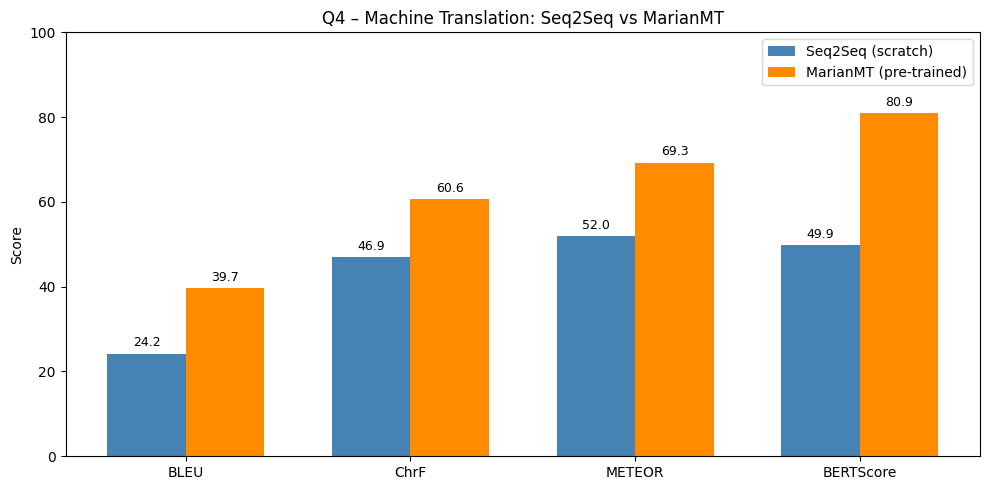

✓ Saved


In [23]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['BLEU', 'ChrF', 'METEOR', 'BERTScore']
seq2seq_vals = [seq2seq_metrics[m] for m in metrics]
marian_vals  = [marian_metrics[m]  for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, seq2seq_vals, width, label='Seq2Seq (scratch)', color='steelblue')
bars2 = ax.bar(x + width/2, marian_vals,  width, label='MarianMT (pre-trained)', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Q4 – Machine Translation: Seq2Seq vs MarianMT')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 100)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('q4_translation/figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

In [24]:
import os
os.chdir('/content/CENG467_Midterm_310201051')

!git add q4_translation/
!git commit -m "Q4: Seq2Seq+Attention vs MarianMT (BLEU=24.21 vs 39.66)"
!git push origin main

print("✓ Done!")

[main 0cd5b4a] Q4: Seq2Seq+Attention vs MarianMT (BLEU=24.21 vs 39.66)
 3 files changed, 26 insertions(+)
 create mode 100644 q4_translation/figures/metrics_comparison.png
 create mode 100644 q4_translation/figures/seq2seq_training_curves.png
 create mode 100644 q4_translation/results/q4_results.json
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (8/8), 121.77 KiB | 12.18 MiB/s, done.
Total 8 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/iremcesur/CENG467_Midterm_310201051.git
   546bb96..0cd5b4a  main -> main
✓ Done!


In [25]:
import os, json, glob
os.chdir('/content/CENG467_Midterm_310201051')

# Güncel notebook'u doğru klasöre kopyala
!cp "/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb" q4_translation/

# Widget metadata temizle
for path in glob.glob('q4_translation/**/*.ipynb', recursive=True):
    with open(path, 'r') as f:
        nb = json.load(f)
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
    with open(path, 'w') as f:
        json.dump(nb, f, indent=1)

!git add q4_translation/
!git commit -m "Q4: update notebook with all cells"
!git push origin main
print("✓ Done")

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb': No such file or directory
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✓ Done


In [26]:
!find /content -name "*.ipynb" 2>/dev/null

/content/CENG467_Midterm_310201051/q1_classification/notebooks/q1_tfidf_baseline.ipynb
/content/CENG467_Midterm_310201051/q1_classification/notebooks/q1_distilbert.ipynb
/content/CENG467_Midterm_310201051/q1_classification/notebooks/q1_bilstm.ipynb
/content/CENG467_Midterm_310201051/00_setup.ipynb
/content/CENG467_Midterm_310201051/q4_translation/q4_seq2seq_nmt.ipynb
/content/CENG467_Midterm_310201051/q2_ner/q2_ner.ipynb
/content/CENG467_Midterm_310201051/q3_summarization/q3_summarization.ipynb
/content/CENG467_Midterm_310201051/q5_language_modeling/q5_language_modeling.ipynb


In [27]:
import os, json, glob
os.chdir('/content/CENG467_Midterm_310201051')

# Notebook'un kaç hücre içerdiğini kontrol et
with open('q4_translation/q4_seq2seq_nmt.ipynb', 'r') as f:
    nb = json.load(f)
print(f"Hücre sayısı: {len(nb['cells'])}")

Hücre sayısı: 1


In [28]:
import os, json, glob
os.chdir('/content/CENG467_Midterm_310201051')

# Widget metadata temizle
for path in glob.glob('q4_translation/**/*.ipynb', recursive=True):
    with open(path, 'r') as f:
        nb = json.load(f)
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
    with open(path, 'w') as f:
        json.dump(nb, f, indent=1)

!git add q4_translation/
!git commit -m "Q4: update notebook with all cells and results"
!git push origin main
print("✓ Done")

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✓ Done


In [29]:
!cp /content/CENG467_Midterm_310201051/q4_translation/q4_seq2seq_nmt.ipynb \
    "/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb"
print("✓ Copied to Drive")

cp: cannot create regular file '/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb': No such file or directory
✓ Copied to Drive


In [30]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [32]:
!cp /content/CENG467_Midterm_310201051/q4_translation/q4_seq2seq_nmt.ipynb \
    "/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb"
print("✓ Copied to Drive")

✓ Copied to Drive


In [33]:
import os, json, glob
os.chdir('/content/CENG467_Midterm_310201051')

for path in glob.glob('q4_translation/**/*.ipynb', recursive=True):
    with open(path, 'r') as f:
        nb = json.load(f)
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
    with open(path, 'w') as f:
        json.dump(nb, f, indent=1)

!git add q4_translation/
!git commit -m "Q4: update notebook with all cells and results"
!git push origin main
print("✓ Done")

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✓ Done


In [34]:
import os, json, glob

# Drive'daki güncel versiyonu repo klasörüne kopyala
!cp "/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb" \
    /content/CENG467_Midterm_310201051/q4_translation/q4_seq2seq_nmt.ipynb

# Hücre sayısını kontrol et
with open('/content/CENG467_Midterm_310201051/q4_translation/q4_seq2seq_nmt.ipynb', 'r') as f:
    nb = json.load(f)
print(f"Hücre sayısı: {len(nb['cells'])}")

Hücre sayısı: 1
